In [5]:
# Brake Lamp Remaining Useful Life (RUL) Classification

#Goal: Predict lamp health stage (Healthy, Warning, Critical) using sensor data.

In [55]:
#Data Understanding
import pandas as pd

df = pd.read_csv("/content/merged_dataset.csv")

df = df.drop(columns=["Unnamed: 0"])

df = df.dropna()

df["Type"] = df["Type"].map({"Continuous": 0, "Alternate": 1})

print("Shape:", df.shape)

display(df.head(10))

Shape: (3005, 19)


,Voltage,Current,Power,Resistance,Filament_Melted,Time_Elapsed,Type,Operating_Hours,Cycles_Count,Resistance_Change,Time_Change,Resistance_Change_Rate,Cumulative_Resistance_Change,Normalized_Resistance,Efficiency,Power_Deviation,Health_Index,Lifetime,RUL
0,22.0,2.40000,52.800000,8.130000,0.0,0.0,0,0.000000,0.0,0.00000,1.0,0.000000,0.000000,1.000000,1.0,0.000000,1.000000,118.0,118.0
1,22.0,2.39950,52.789000,8.150000,0.0,2.0,0,0.033333,0.0,0.02000,2.0,0.010000,0.020000,1.002460,1.0,-0.000208,0.987700,118.0,116.0
2,22.0,2.39899,52.777780,8.170010,0.0,4.0,0,0.066667,0.0,0.02001,2.0,0.010005,0.040010,1.004921,1.0,-0.000421,0.975394,118.0,114.0
3,22.0,2.39847,52.766340,8.190030,0.0,6.0,0,0.100000,0.0,0.02002,2.0,0.010010,0.060030,1.007384,1.0,-0.000637,0.963081,118.0,112.0
4,22.0,2.39794,52.754680,8.210060,0.0,8.0,0,0.133333,0.0,0.02003,2.0,0.010015,0.080060,1.009847,1.0,-0.000858,0.950763,118.0,110.0
5,22.0,2.39740,52.742800,8.230100,0.0,10.0,0,0.166667,0.0,0.02004,2.0,0.010020,0.100100,1.012312,1.0,-0.001083,0.938438,118.0,108.0
6,22.0,2.39685,52.730701,8.250150,0.0,12.0,0,0.200000,0.0,0.02005,2.0,0.010025,0.120150,1.014779,1.0,-0.001312,0.926107,118.0,106.0
7,22.0,2.39629,52.718382,8.270210,0.0,14.0,0,0.233333,0.0,0.02006,2.0,0.010030,0.140210,1.017246,1.0,-0.001546,0.913770,118.0,104.0
8,22.0,2.39572,52.705843,8.290279,0.0,16.0,0,0.266667,0.0,0.02007,2.0,0.010035,0.160279,1.019715,1.0,-0.001783,0.901427,118.0,102.0
9,22.0,2.39514,52.693085,8.310359,0.0,18.0,0,0.300000,0.0,0.02008,2.0,0.010040,0.180359,1.022184,1.0,-0.002025,0.889078,118.0,100.0


In [56]:
#No. of lamp detection

# Detect where new lamp starts
df["New_Lamp"] = (df["Time_Elapsed"] == 0).astype(int)

# Create Lamp ID
df["Lamp_ID"] = df["New_Lamp"].cumsum()

print("Total lamps:", df["Lamp_ID"].nunique())

display(df[["Time_Elapsed", "RUL", "Lamp_ID"]].head(155))

Total lamps: 17


,Time_Elapsed,RUL,Lamp_ID
0,0.0,118.0,1
1,2.0,116.0,1
2,4.0,114.0,1
3,6.0,112.0,1
4,8.0,110.0,1
...,...,...,...
150,180.0,4.0,2
151,182.0,2.0,2
152,184.0,0.0,2
153,0.0,334.0,3


In [57]:
print(df["Lamp_ID"].unique())

train_lamps = df["Lamp_ID"].unique()[:13]
test_lamps = df["Lamp_ID"].unique()[13:]

train_df = df[df["Lamp_ID"].isin(train_lamps)]
test_df = df[df["Lamp_ID"].isin(test_lamps)]

#prints
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain lamps:", train_lamps)
print("Test lamps:", test_lamps)

[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17]
Train shape: (2535, 21)
Test shape: (470, 21)

Train lamps: [ 1  2  3  4  5  6  7  8  9 10 11 12 13]
Test lamps: [14 15 16 17]


In [58]:
#Identifying features that help model cheat and see the target values beforehand
leakage_features = [
    "Lifetime",
    "Health_Index",
    "Cumulative_Resistance_Change",
    "Normalized_Resistance",
    "Efficiency"
]

train_df = train_df.drop(columns=leakage_features)
test_df = test_df.drop(columns=leakage_features)

print("Train columns:", train_df.columns)
print("Test columns:", test_df.columns)

Train columns: Index(['Voltage', 'Current', 'Power', 'Resistance', 'Filament_Melted',
       'Time_Elapsed', 'Type', 'Operating_Hours', 'Cycles_Count',
       'Resistance_Change', 'Time_Change', 'Resistance_Change_Rate',
       'Power_Deviation', 'RUL', 'New_Lamp', 'Lamp_ID'],
      dtype='object')
Test columns: Index(['Voltage', 'Current', 'Power', 'Resistance', 'Filament_Melted',
       'Time_Elapsed', 'Type', 'Operating_Hours', 'Cycles_Count',
       'Resistance_Change', 'Time_Change', 'Resistance_Change_Rate',
       'Power_Deviation', 'RUL', 'New_Lamp', 'Lamp_ID'],
      dtype='object')


In [59]:
# Prepare features and target

# Target
y_train = train_df["RUL"]
y_test = test_df["RUL"]

# Droping target + non-sensor columns
drop_cols = ["RUL", "Lamp_ID", "New_Lamp"]

X_train = train_df.drop(columns=drop_cols)
X_test = test_df.drop(columns=drop_cols)

#prints
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nFeatures used:")
print(X_train.columns)

X_train shape: (2535, 13)
X_test shape: (470, 13)

Features used:
Index(['Voltage', 'Current', 'Power', 'Resistance', 'Filament_Melted',
       'Time_Elapsed', 'Type', 'Operating_Hours', 'Cycles_Count',
       'Resistance_Change', 'Time_Change', 'Resistance_Change_Rate',
       'Power_Deviation'],
      dtype='object')


In [60]:
#Converting RUL into categories

def classify_rul(rul):
    if rul > 200:
        return 2   # Healthy
    elif rul > 50:
        return 1   # Warning
    else:
        return 0   # Critical

train_df["RUL_class"] = train_df["RUL"].apply(classify_rul)
test_df["RUL_class"] = test_df["RUL"].apply(classify_rul)

print(train_df["RUL_class"].value_counts())

RUL_class
2    1229
1     959
0     347
Name: count, dtype: int64


In [63]:
# Step 14: Prepare classification features

y_train_class = train_df["RUL_class"]
y_test_class = test_df["RUL_class"]

# X is same as before
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (2535, 13)
Test shape: (470, 13)


In [64]:
#training Xgboost classifier model
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

clf = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)

# Train
clf.fit(X_train, y_train_class)

# Predict
y_pred_class = clf.predict(X_test)

# Evaluation
acc = accuracy_score(y_test_class, y_pred_class)
print("Accuracy:", acc)

print("\nClassification report:")
print(classification_report(y_test_class, y_pred_class))

Accuracy: 0.43617021276595747

Classification report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       198
           1       0.51      0.75      0.61       272
           2       0.00      0.00      0.00         0

    accuracy                           0.44       470
   macro avg       0.17      0.25      0.20       470
weighted avg       0.29      0.44      0.35       470



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [65]:
#shuffling lamps expecting better accuracy
import numpy as np

lamp_ids = df["Lamp_ID"].unique()

# Shuffle lamps
np.random.seed(42)
np.random.shuffle(lamp_ids)

# 80% train
split = int(0.8 * len(lamp_ids))
train_lamps = lamp_ids[:split]
test_lamps = lamp_ids[split:]

train_df = df[df["Lamp_ID"].isin(train_lamps)]
test_df = df[df["Lamp_ID"].isin(test_lamps)]

print("Train lamps:", train_lamps)
print("Test lamps:", test_lamps)

Train lamps: [ 1  2  6 16 12 15  9 14  3 10 17  5  8]
Test lamps: [11 13  4  7]


In [66]:
# Recreate classification labels after new split

def classify_rul(rul):
    if rul > 200:
        return 2   # Healthy
    elif rul > 50:
        return 1   # Warning
    else:
        return 0   # Critical

train_df["RUL_class"] = train_df["RUL"].apply(classify_rul)
test_df["RUL_class"] = test_df["RUL"].apply(classify_rul)

print(train_df["RUL_class"].value_counts())
print(test_df["RUL_class"].value_counts())

RUL_class
1    914
2    854
0    467
Name: count, dtype: int64
RUL_class
2    375
1    317
0     78
Name: count, dtype: int64


/tmp/ipykernel_9390/331561624.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["RUL_class"] = train_df["RUL"].apply(classify_rul)
/tmp/ipykernel_9390/331561624.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df["RUL_class"] = test_df["RUL"].apply(classify_rul)


In [67]:
# Rebuild X and y after new split

# Targets
y_train_class = train_df["RUL_class"]
y_test_class = test_df["RUL_class"]

# Drop non-feature columns
drop_cols = ["RUL", "Lamp_ID", "New_Lamp", "RUL_class"]

X_train = train_df.drop(columns=drop_cols)
X_test = test_df.drop(columns=drop_cols)

print("X_train:", X_train.shape)
print("y_train:", y_train_class.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test_class.shape)

X_train: (2235, 18)
y_train: (2235,)
X_test: (770, 18)
y_test: (770,)


In [68]:
clf.fit(X_train, y_train_class)

y_pred_class = clf.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

acc = accuracy_score(y_test_class, y_pred_class)
print("Accuracy:", acc)

print("\nClassification report:")
print(classification_report(y_test_class, y_pred_class))

Accuracy: 0.6506493506493507

Classification report:
              precision    recall  f1-score   support

           0       1.00      0.21      0.34        78
           1       0.63      0.56      0.60       317
           2       0.65      0.82      0.72       375

    accuracy                           0.65       770
   macro avg       0.76      0.53      0.55       770
weighted avg       0.68      0.65      0.63       770



<Figure size 600x500 with 0 Axes>

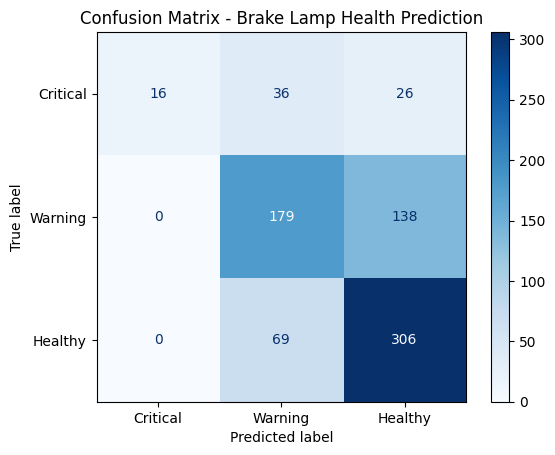

In [69]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_class, y_pred_class)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Critical", "Warning", "Healthy"])

plt.figure(figsize=(6,5))
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Brake Lamp Health Prediction")
plt.show()

In [70]:
#Additional new Approach
#Automatic class imbalance handaling
from sklearn.utils import compute_class_weight
import numpy as np
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, recall_score

# compute class weights (for labels present in y_train_class)
classes = np.unique(y_train_class)
class_weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train_class)
cw = dict(zip(classes, class_weights))
print("Class weights:", cw)

# build sample weights vector
sample_weight = y_train_class.map(cw).values

#train classifier with sample weights
clf_w = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, use_label_encoder=False, eval_metric="mlogloss")
clf_w.fit(X_train, y_train_class, sample_weight=sample_weight)

# predict and evaluate
y_pred_w = clf_w.predict(X_test)

print("Classification report (weighted):")
print(classification_report(y_test_class, y_pred_w))

cm_w = confusion_matrix(y_test_class, y_pred_w)
print("Confusion matrix:\n", cm_w)
print("Critical recall:", recall_score(y_test_class, y_pred_w, labels=[0,1,2], average=None)[0])

Class weights: {np.int64(0): np.float64(1.595289079229122), np.int64(1): np.float64(0.8150984682713348), np.int64(2): np.float64(0.8723653395784543)}


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:39:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification report (weighted):
              precision    recall  f1-score   support

           0       0.73      0.83      0.78        78
           1       0.69      0.56      0.62       317
           2       0.73      0.82      0.77       375

    accuracy                           0.71       770
   macro avg       0.71      0.74      0.72       770
weighted avg       0.71      0.71      0.71       770

Confusion matrix:
 [[ 65  13   0]
 [ 24 179 114]
 [  0  69 306]]
Critical recall: 0.8333333333333334


In [71]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance from weighted model
importance = clf_w.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

                         Feature  Importance
17                      Lifetime    0.522758
1                        Current    0.091453
16                  Health_Index    0.082848
13         Normalized_Resistance    0.064921
3                     Resistance    0.059661
5                   Time_Elapsed    0.033713
15               Power_Deviation    0.030243
11        Resistance_Change_Rate    0.024857
8                   Cycles_Count    0.021225
0                        Voltage    0.020652
9              Resistance_Change    0.014558
12  Cumulative_Resistance_Change    0.013007
2                          Power    0.007961
6                           Type    0.006258
14                    Efficiency    0.005762
10                   Time_Change    0.000123
7                Operating_Hours    0.000000
4                Filament_Melted    0.000000


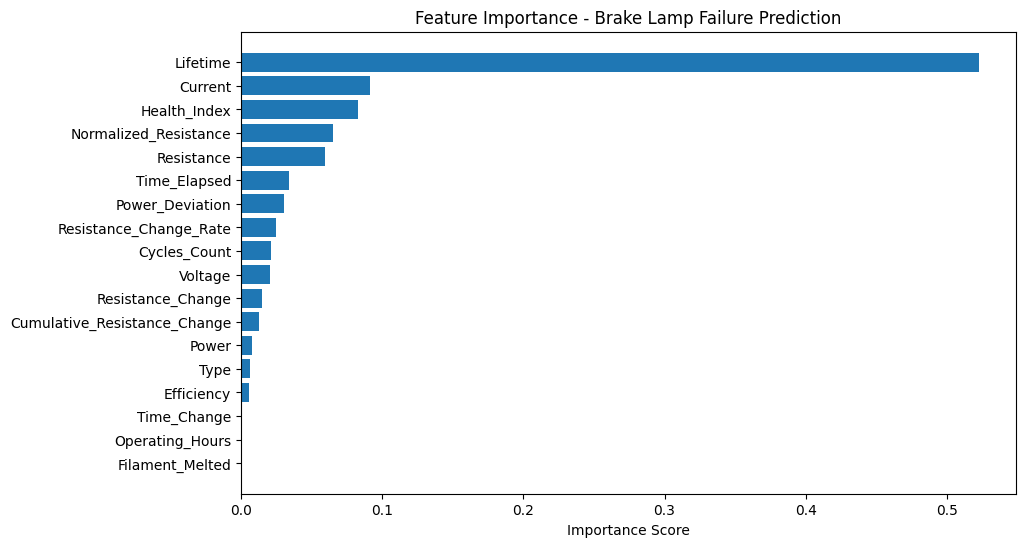

In [72]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Brake Lamp Failure Prediction")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
#still the model is cheating since we can see that feature importance is lifetime which is a target variable

In [73]:
#Dropping leakage features from train and test data
leakage_features = ["Lifetime", "Health_Index", "Normalized_Resistance"]

X_train = X_train.drop(columns=leakage_features)
X_test = X_test.drop(columns=leakage_features)

print("New feature shape:", X_train.shape)

New feature shape: (2235, 15)


In [74]:
#retrain
clf_w.fit(X_train, y_train_class, sample_weight=sample_weight)

y_pred_w = clf_w.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_class, y_pred_w))
print(confusion_matrix(y_test_class, y_pred_w))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:40:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.54      0.55      0.54        78
           1       0.85      0.62      0.71       317
           2       0.82      1.00      0.90       375

    accuracy                           0.80       770
   macro avg       0.73      0.72      0.72       770
weighted avg       0.80      0.80      0.79       770

[[ 43  35   0]
 [ 37 195  85]
 [  0   0 375]]


In [75]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance from weighted model
importance = clf_w.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feature_importance)

                         Feature  Importance
14               Power_Deviation    0.415697
9              Resistance_Change    0.152190
3                     Resistance    0.100976
1                        Current    0.083388
12  Cumulative_Resistance_Change    0.059941
5                   Time_Elapsed    0.058756
0                        Voltage    0.036914
8                   Cycles_Count    0.029473
2                          Power    0.021122
13                    Efficiency    0.019653
6                           Type    0.016894
11        Resistance_Change_Rate    0.004995
4                Filament_Melted    0.000000
10                   Time_Change    0.000000
7                Operating_Hours    0.000000


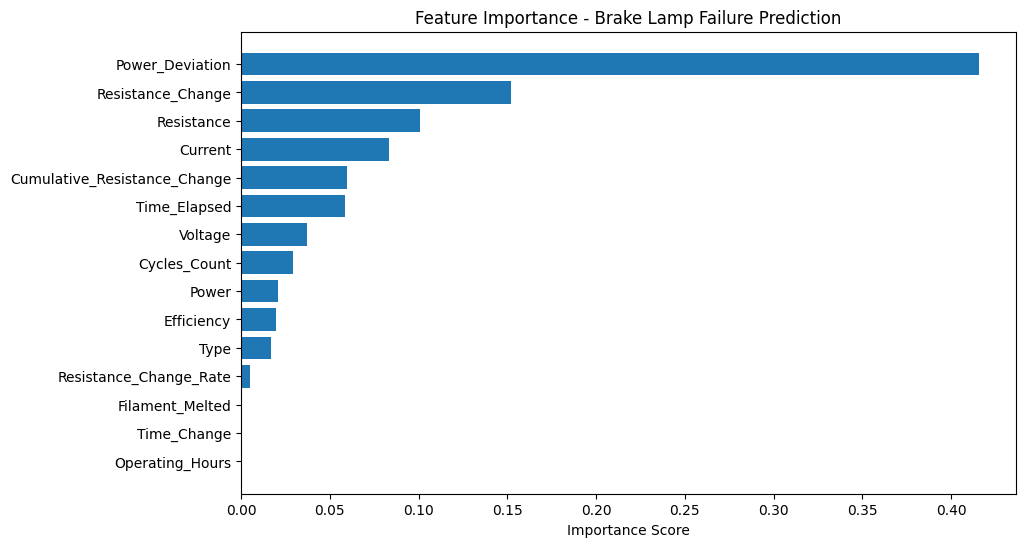

In [76]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Brake Lamp Failure Prediction")
plt.xlabel("Importance Score")
plt.show()

In [ ]:
#Now feature importance looks realistic

In [77]:
# Now feature importance improved drastically showing that the model is now not cheating and accuracy reached to 80%